
###                                                   **GAMZE ÖNDER**

## ***Task 1 ~ Story***

<div class="alert alert-block alert-success">

#### **The Story: Enhancing Amazon's Recommendation System**

##### **Context:**
As a data scientist at Amazon, I am part of a specialized team focused on improving the product recommendation system. Our project aims at predicting potential co-purchases to enhance the accuracy of recommendations. By analyzing the purchasing patterns of users, we hope to identify products that are likely to be bought together, thus optimizing Amazon’s recommendation algorithm.

#### **Project Overview**
##### **Project Aim:**
The main goal of this project is to predict new edges in the Amazon product co-purchasing network, representing potential co-purchase relationships between products. This prediction aims to refine Amazon's recommendation engine, ensuring more relevant product suggestions.

##### **Value Creation:**
The primary purpose of this experiment is to improve the recommendation system’s ability to suggest relevant products to customers. Accurate prediction of new co-purchase relationships aims to:

- **Enhance Customer Experience:** Deliver a more personalized shopping experience.
- **Increase Sales:** More relevant recommendations increase the likelihood of additional purchases.
- **Optimize Inventory Management:** Better prediction of co-purchase patterns can inform inventory decisions, ensuring popular product combinations are well-stocked.

#### **Experiment Plan**
##### **Data Preparation:**
- **Extract a Random Sample:** Focus on 200 nodes and their corresponding edges from the Amazon product co-purchasing network.

##### **Graph Analysis:**
- **Initial Data Analysis (IDA):** Conduct a comprehensive analysis of the sampled graph to understand its properties. Focus on key metrics such as the number of nodes and edges, graph density, average clustering coefficient, and the number and size of strongly and weakly connected components.
- **Node Degree Calculation:** Calculate the degree of each node to identify products with the highest co-purchase relationships. This helps in understanding which products are most frequently bought together and can be critical for graph properties and central nodes analysis.

#### **Graph Properties and Central Nodes Analysis:**
##### **Graph Properties:**

- **Degree Distribution:** Examines how many co-purchase relationships each product (node) has.
- **Density:** Indicates how interconnected the products are based on co-purchases.
- **Clustering Coefficient:** Measures how products tend to form clusters or groups in the network.
- **Average Path Length:** Shows the average distance between products in terms of co-purchases.
- **Transitivity:** Indicates how likely products are to form triangles of co-purchases.
- **Assortativity:** Reflects whether products with similar characteristics tend to co-purchase more.

##### **Central Nodes Analysis:**

- **Degree Centrality:** Identifies products with the most direct co-purchase relationships.
- **Betweenness Centrality:** Highlights products that act as bridges between different groups of co-purchasing products.
- **Closeness Centrality:** Measures how quickly a product can interact with others through co-purchases.
- **Eigenvector Centrality:** Shows products that are connected to other highly connected products.
- **Hub and Authority Scores (HITS Algorithm):** Identifies products that are frequently co-purchased with many others (hubs) and those that are commonly bought together (authorities).

##### **Model Training:**
- **Training Data:** Use the existing edges as positive examples and randomly sampled non-edges as negative examples.
- **Machine Learning Model:** Train models (e.g., logistic regression, random forest) to predict the probability of an edge forming between two nodes.

##### **Prediction and Evaluation:**
- **Prediction:** Apply the trained models to predict new potential edges in the sampled graph.
- **Evaluation:** Assess the models’ performance using metrics like accuracy, precision, recall, and AUC-ROC.


#### **Expected Value:**
If successful, this graph analysis and edge prediction will enable Amazon to:
- **Drive Sales Growth:** Improved recommendations are likely to increase the average order value as customers are more inclined to purchase additional items.
- **Enhance Customer Retention:** Personalized recommendations enhance user satisfaction, potentially increasing customer retention rates.
- **Improve Operational Efficiency:** Insights from co-purchase predictions can streamline inventory management, ensuring that frequently bought-together items are always in stock, thus reducing supply chain inefficiencies.


This experiment’s ultimate goal is to leverage graph analysis to refine Amazon’s recommendation system, creating a more engaging shopping experience for customers and driving significant value for the organization. By focusing on a representative sample of 200 nodes, the approach remains scalable and can be incrementally expanded to the entire network, ensuring robustness and adaptability in a real-world scenario.

## *Task 2 ~ The Data*

<div class="alert alert-block alert-warning">

#### **Dataset Description:**

The dataset, named "[Amazon0302.txt](https://snap.stanford.edu/data/amazon0302.html)" represents the co-purchasing network of products on Amazon from March 02, 2003. It is a directed graph where each unordered pair of nodes is saved once. The dataset consists of nodes and edges, with nodes representing unique products available on Amazon and edges representing co-purchases between products. The dataset contains a total of 262,111 nodes and 1,234,877 edges.

#### **Format:**

**The dataset is formatted as follows:**

- Each row represents an edge in the graph.
- The first row contains metadata about the dataset, such as the number of nodes and edges.
- The subsequent rows contain pairs of node IDs representing directed edges from one product (FromNodeId) to another product (ToNodeId).
- For example, the row "0 1" indicates that there is an edge from node 0 to node 1, meaning that product 0 is frequently purchased together with product 1.

#### **Suitability for Task 1:**

**1. Graph Analysis:** The dataset is suitable for graph analysis as it represents a network structure where nodes and edges capture relationships between products based on co-purchasing behavior. Graph analysis techniques can be applied to uncover patterns, structures, and relationships within the co-purchasing network.

**2. Edge Prediction:** With the co-purchasing network data, machine learning models can be developed to predict potential edges (co-purchases) within the graph. By leveraging historical co-purchasing data, these models can predict which products are likely to be purchased together in the future, enhancing Amazon's recommendation system.

**3. Evaluation:** The performance of edge prediction models can be evaluated using metrics such as accuracy, precision, and recall. This evaluation ensures that the models effectively capture significant relationships within the co-purchasing network and provide valuable insights for improving the recommendation system.

**4. Integration:** Insights derived from graph analysis and edge prediction can be integrated into Amazon's recommendation system. By incorporating these insights, the recommendation system can deliver more personalized and relevant product recommendations to users, thereby improving customer satisfaction and driving sales.

Overall, the dataset provides valuable information about product co-purchasing behavior on Amazon, making it suitable for the tasks outlined in Task 1.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
#from edge_split import EdgeSplitter  
from node2vec import Node2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Load the dataset
#G = nx.read_edgelist('amazon0302.txt/Amazon0302.txt', create_using=nx.Graph(), nodetype=int)
G = nx.read_edgelist('amazon0302.txt/Amazon0302.txt', create_using=nx.DiGraph())

In [3]:
# Filter the graph to include only a subset of nodes and edges
def filter_graph(G, criteria):
    filtered_edges = [(u, v) for u, v in G.edges() if criteria(u, v)]
    H = G.edge_subgraph(filtered_edges)
    return H

# Define a criteria function to filter edges based on a condition
def criteria(u, v):
    #Include only edges where the source node is less than 200
    return int(u) < 200

In [4]:
# Visualize the filtered graph
def visualize_filtered_graph(G):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, seed=42)  # For consistent layout
    nx.draw(G, pos, with_labels=True, node_size=5000, node_color='lightblue', font_size=8, font_weight='bold', edge_color='gray')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title('Amazon Product Co-Purchasing Network')
    plt.show()

In [5]:
# Analyze the filtered graph
def analyze_filtered_graph(G):
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())
    print("Density of the graph:", nx.density(G))
    
    # In-degree and Out-degree distribution
    in_degree_sequence = sorted([d for n, d in G.in_degree()], reverse=True)
    out_degree_sequence = sorted([d for n, d in G.out_degree()], reverse=True)
    print("Maximum in-degree:", max(in_degree_sequence))
    print("Minimum in-degree:", min(in_degree_sequence))
    print("Average in-degree:", sum(in_degree_sequence) / len(in_degree_sequence))
    print("Maximum out-degree:", max(out_degree_sequence))
    print("Minimum out-degree:", min(out_degree_sequence))
    print("Average out-degree:", sum(out_degree_sequence) / len(out_degree_sequence))

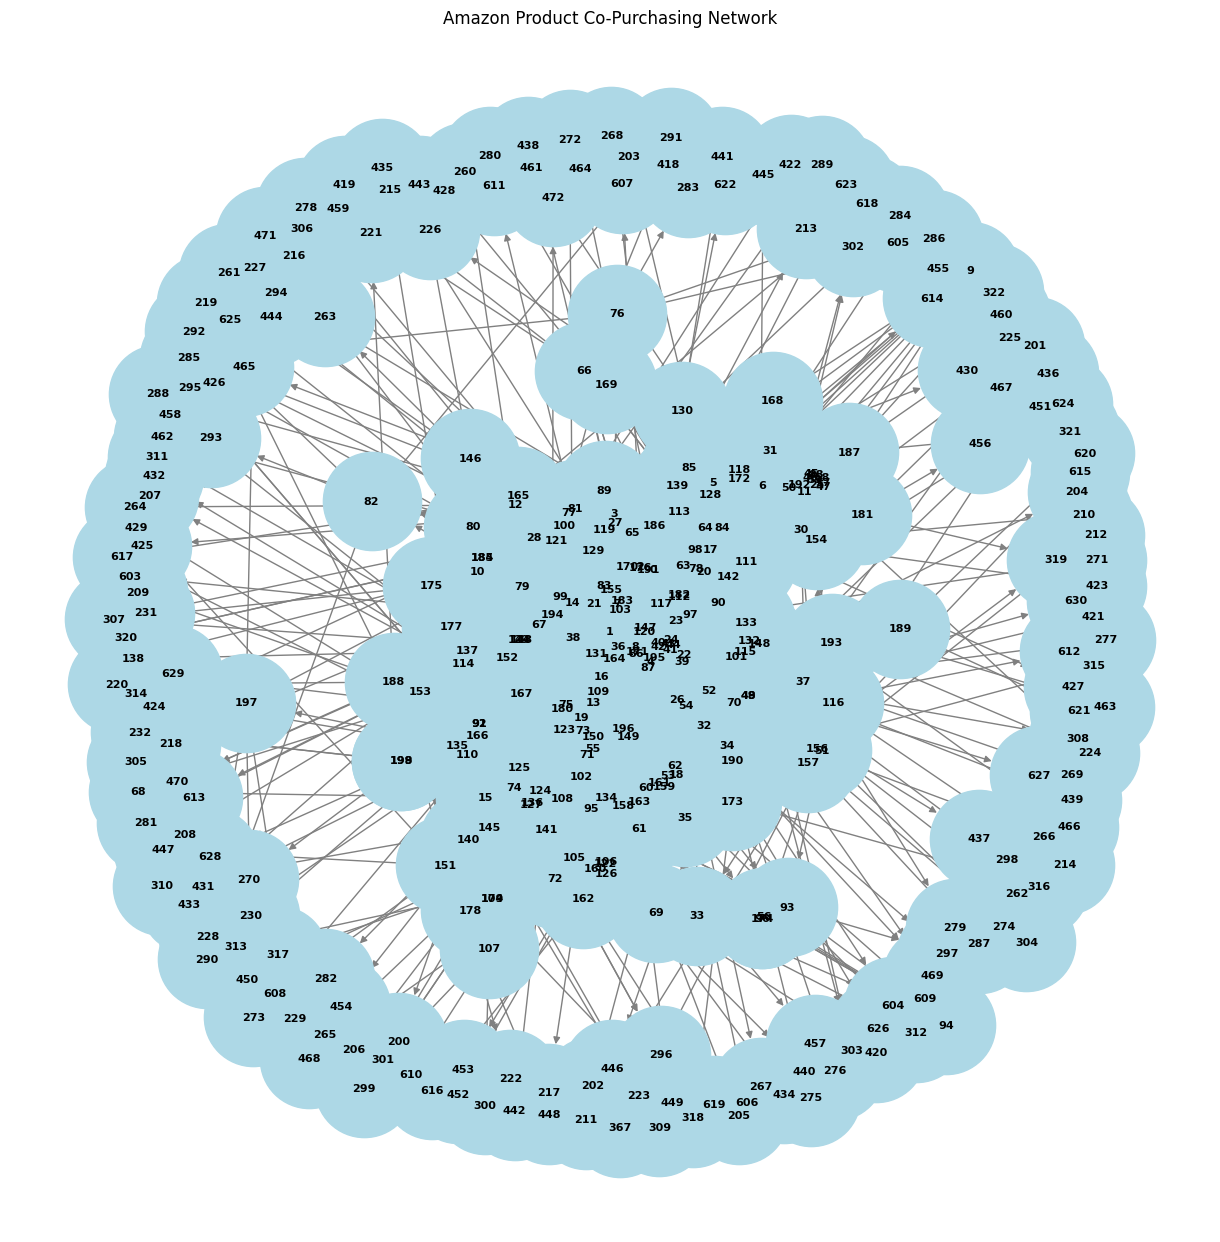

Number of nodes: 380
Number of edges: 979
Density of the graph: 0.006797666990695736
Maximum in-degree: 21
Minimum in-degree: 1
Average in-degree: 2.5763157894736843
Maximum out-degree: 5
Minimum out-degree: 0
Average out-degree: 2.5763157894736843


In [6]:
# Filter the graph
filtered_G = filter_graph(G, criteria)

# Visualize and analyze the filtered graph
visualize_filtered_graph(filtered_G)
analyze_filtered_graph(filtered_G)

- The dataset consists of 380 unique products and 979 co-purchasing relationships between them.

- The density of the graph is relatively low, indicating that the number of observed co-purchasing relationships is sparse compared to the total possible connections between products.

- The maximum in-degree is 21, which means that the highest number of edges pointing towards a node is 21.

- The minimum in-degree is 1, indicating that at least one product has only one incoming edge.

- The average in-degree is approximately 2.58, representing the average number of edges directed towards each node.

- The maximum out-degree is 5, indicating that the highest number of edges originating from a node is 5.

- The minimum out-degree is 0, suggesting that there are nodes without any outgoing edges.

- The average out-degree is approximately 2.58, representing the average number of edges originating from each node.


## *Task 3 ~ Initial Data Analysis (IDA)*

Number of nodes: 262111
Number of edges: 1234877
Density: 1.7974419114806206e-05


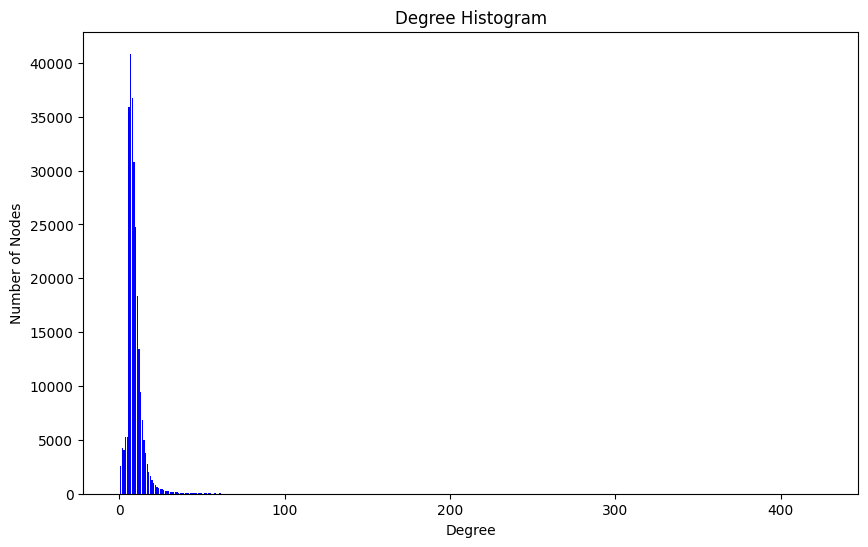

Average Clustering Coefficient: 0.3468794075698955
Number of strongly connected components: 6594
Largest strongly connected component size: 241761
Number of weakly connected components: 1
Largest weakly connected component size: 262111
Number of connected components: 1
Largest connected component size: 262111


In [7]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

print(f'Number of nodes: {num_nodes}')
print(f'Number of edges: {num_edges}')
print(f'Density: {density}')

# Degree distribution
degrees = [degree for node, degree in G.degree()]
degree_hist = nx.degree_histogram(G)
plt.figure(figsize=(10, 6))
plt.bar(range(len(degree_hist)), degree_hist, width=0.8, color='b')
plt.title('Degree Histogram')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.show()

# Average clustering coefficient
avg_clustering = nx.average_clustering(G)
print(f'Average Clustering Coefficient: {avg_clustering}')

# The number of strongly connected components
num_scc = nx.number_strongly_connected_components(G)
largest_scc = max(nx.strongly_connected_components(G), key=len)
print(f'Number of strongly connected components: {num_scc}')
print(f'Largest strongly connected component size: {len(largest_scc)}')

# The number of weakly connected components
num_wcc = nx.number_weakly_connected_components(G)
largest_wcc = max(nx.weakly_connected_components(G), key=len)
print(f'Number of weakly connected components: {num_wcc}')
print(f'Largest weakly connected component size: {len(largest_wcc)}')

G_undirected = G.to_undirected()

#The number of connected components
num_connected_components = nx.number_connected_components(G_undirected)
largest_cc = max(nx.connected_components(G_undirected), key=len)
print(f'Number of connected components: {num_connected_components}')
print(f'Largest connected component size: {len(largest_cc)}')


- The histogram represents the degree distribution of nodes in a graph. 
- The degree distribution is heavily skewed to the right, indicating that most nodes have a low degree.
- There is a very high frequency of nodes with a degree close to zero.
- A small number of nodes have a very high degree, creating a long tail extending towards higher degrees.

For full of dataset G, with 262,111 nodes and 1,234,877 edges, where nodes represent individual products and edges indicate co-purchasing relationships:

- The graph's density is 1.7974419114806206e-05, indicating a sparse network with most product pairs not being co-purchased together. 

- The degree distribution, visualized through a histogram, shows the number of connections each product has, highlighting the connectivity patterns. 

- The average clustering coefficient is 0.3468794075698955, suggesting that products tend to cluster together, indicating common co-purchasing behavior. 

- The graph has several strongly connected components (SCCs), with the largest SCC indicating the subgraph where each product can reach every other product following directed edges. There are also weakly connected components (WCCs) and connected components in the undirected version of the graph, showing overall connectivity without considering edge direction. 

- The largest connected component in the undirected graph includes most nodes, demonstrating significant overall connectivity in the product co-purchasing network.

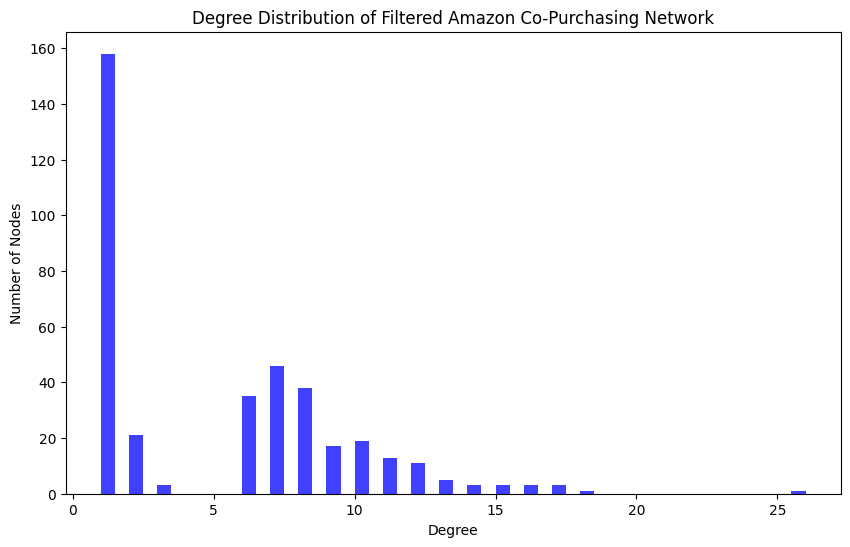

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# Degree distribution
degrees = [degree for node, degree in filtered_G.degree()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50, alpha=0.75, color='blue')
plt.title('Degree Distribution of Filtered Amazon Co-Purchasing Network')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.show()




Number of nodes: 380
Number of edges: 979
Density of the graph: 0.006797666990695736


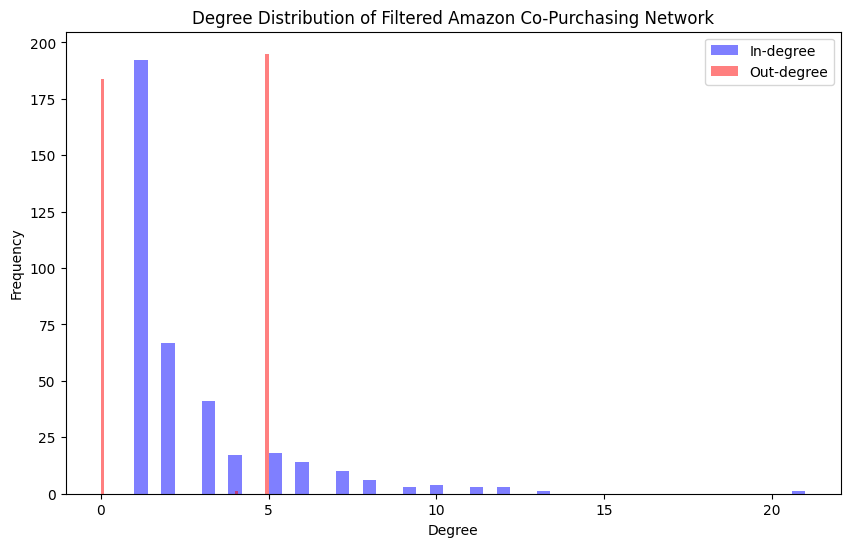

Average Clustering Coefficient: 0.2174227274544363
Number of strongly connected components: 207
Largest strongly connected component size: 123
Number of weakly connected components: 1
Largest weakly connected component size: 380


In [9]:
print("Number of nodes:", filtered_G.number_of_nodes())
print("Number of edges:", filtered_G.number_of_edges())
print("Density of the graph:", nx.density(filtered_G))

# In-degree and Out-degree distribution
in_degrees = [d for n, d in filtered_G.in_degree()]
out_degrees = [d for n, d in filtered_G.out_degree()]

# Plot degree distributions
plt.figure(figsize=(10, 6))
plt.hist(in_degrees, bins=50, alpha=0.5, color='blue', label='In-degree')
plt.hist(out_degrees, bins=50, alpha=0.5, color='red', label='Out-degree')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution of Filtered Amazon Co-Purchasing Network')
plt.legend()
plt.show()


# Average clustering coefficient
avg_clustering = nx.average_clustering(filtered_G)
print(f'Average Clustering Coefficient: {avg_clustering}')

# Compute the number of strongly connected components
num_scc = nx.number_strongly_connected_components(filtered_G)
largest_scc = max(nx.strongly_connected_components(filtered_G), key=len)
print(f'Number of strongly connected components: {num_scc}')
print(f'Largest strongly connected component size: {len(largest_scc)}')

# Compute the number of weakly connected components
num_wcc = nx.number_weakly_connected_components(filtered_G)
largest_wcc = max(nx.weakly_connected_components(filtered_G), key=len)
print(f'Number of weakly connected components: {num_wcc}')
print(f'Largest weakly connected component size: {len(largest_wcc)}')

The histogram represents the degree distribution of the filtered Amazon co-purchasing network, showing both in-degree and out-degree distributions. 

**In-Degree Distribution (Blue Bars):**

- Most nodes have a low in-degree, with a significant number having an in-degree of 0 or 1.
- As the in-degree increases, the frequency of nodes decreases sharply.
- There are a few nodes with higher in-degrees, but they are much less frequent.

**Out-Degree Distribution (Red Bars):**

- There are notable peaks at specific out-degree values.
- The overall frequency of out-degrees is lower compared to in-degrees, but certain out-degree values appear more prominently.

For the filtered dataset, with 380 nodes and 979 edges, where nodes represent individual products and edges indicate co-purchasing relationships:

- The graph's density is 0.006797666990695736, indicating a relatively sparse network with most product pairs not being co-purchased together.

- The average clustering coefficient is 0.2174227274544363, suggesting that products tend to cluster together, indicating common co-purchasing behavior.

- The graph has 207 strongly connected components (SCCs), with the largest SCC containing 123 nodes, indicating the largest subgraph where each product can reach every other product following directed edges.

- There is only one weakly connected component (WCC), which includes all 380 nodes, demonstrating that the overall graph is connected if edge direction is ignored.

As we can see, filtering the dataset reduces computational load and helps focus on important co-purchasing patterns. This makes it easier to improve product recommendations, leading to better customer satisfaction and higher sales.

Using node 1 for the ego graph.


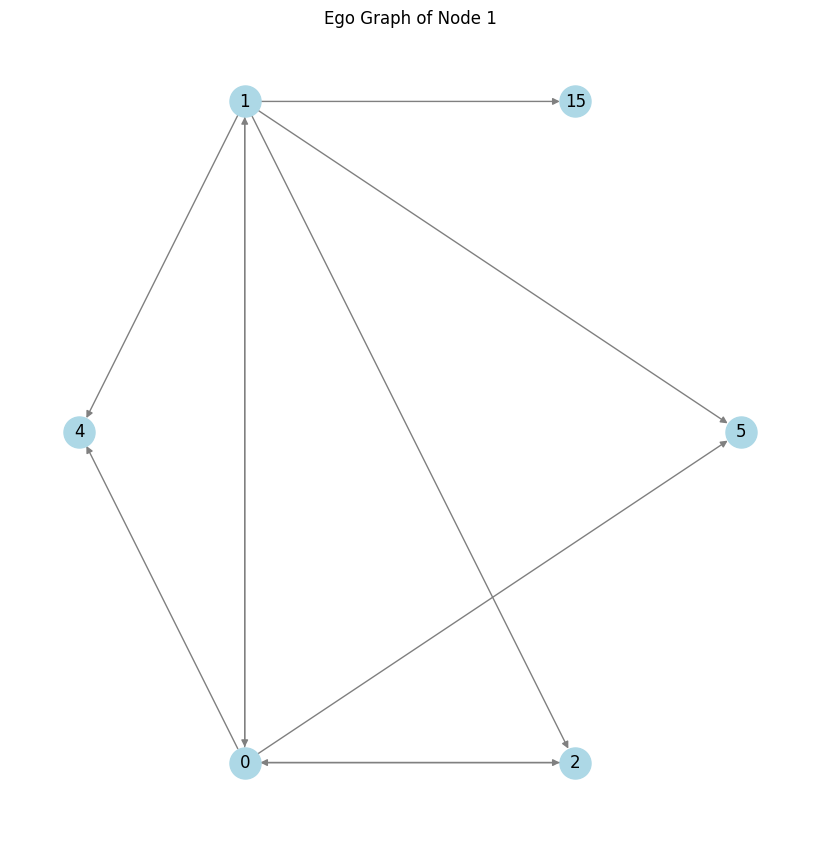

In [10]:
# Use an existing node (e.g., the first node from the list above)
existing_node = list(G.nodes)[1]
print(f"Using node {existing_node} for the ego graph.")

# Neighborhood of the chosen node
ego_graph = nx.ego_graph(G, existing_node)

# Plot the ego graph with circular layout
plt.figure(figsize=(8, 8))
pos = nx.circular_layout(ego_graph)
nx.draw(ego_graph, pos, node_color='lightblue', with_labels=True, node_size=500, edge_color='gray')
plt.title(f'Ego Graph of Node {existing_node}')
plt.show()

Using node 173 for the ego graph.


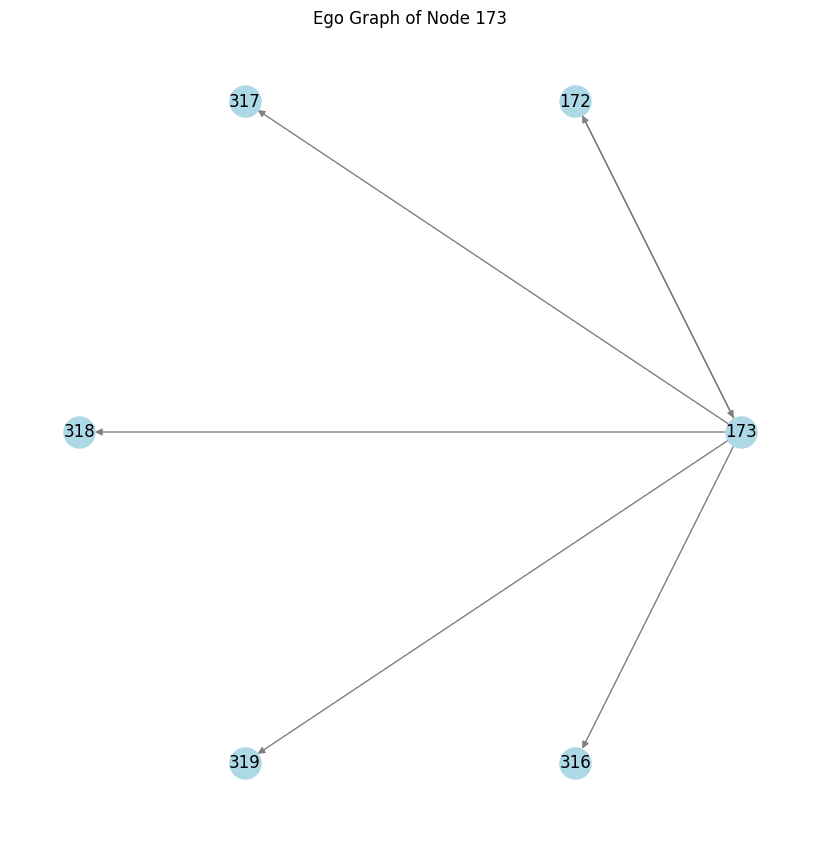

In [11]:
# Use an existing node (e.g., the first node from the list above)
existing_node = list(filtered_G.nodes)[1]
print(f"Using node {existing_node} for the ego graph.")

# Neighborhood of the chosen node
ego_graph = nx.ego_graph(filtered_G, existing_node)

# Plot the ego graph with circular layout
plt.figure(figsize=(8, 8))
pos = nx.circular_layout(ego_graph)
nx.draw(ego_graph, pos, node_color='lightblue', with_labels=True, node_size=500, edge_color='gray')
plt.title(f'Ego Graph of Node {existing_node}')
plt.show()

- This code gives a different ego graph each time due to different nodes. I think there's no problem with that, but I just wanted to let you know that if you're only seeing nodes as a point, you can restart the experipents_graph file.

In [12]:
existing_node = list(filtered_G.nodes)
existing_node

['438',
 '173',
 '229',
 '93',
 '163',
 '471',
 '74',
 '608',
 '39',
 '222',
 '619',
 '230',
 '464',
 '231',
 '309',
 '267',
 '8',
 '436',
 '20',
 '627',
 '138',
 '146',
 '444',
 '157',
 '449',
 '624',
 '2',
 '441',
 '433',
 '129',
 '126',
 '266',
 '5',
 '216',
 '419',
 '57',
 '288',
 '65',
 '312',
 '448',
 '86',
 '34',
 '454',
 '467',
 '124',
 '172',
 '21',
 '83',
 '101',
 '290',
 '53',
 '629',
 '316',
 '611',
 '79',
 '610',
 '460',
 '445',
 '28',
 '421',
 '618',
 '616',
 '424',
 '56',
 '307',
 '16',
 '75',
 '466',
 '283',
 '125',
 '62',
 '35',
 '148',
 '48',
 '102',
 '96',
 '175',
 '214',
 '147',
 '149',
 '7',
 '10',
 '141',
 '110',
 '264',
 '275',
 '136',
 '440',
 '298',
 '191',
 '300',
 '42',
 '165',
 '103',
 '108',
 '227',
 '204',
 '46',
 '188',
 '225',
 '276',
 '99',
 '13',
 '311',
 '310',
 '44',
 '469',
 '109',
 '221',
 '45',
 '140',
 '51',
 '195',
 '1',
 '47',
 '630',
 '12',
 '294',
 '36',
 '626',
 '33',
 '439',
 '219',
 '272',
 '322',
 '218',
 '23',
 '22',
 '615',
 '156',
 '15

## *Task 4 ~ Graph Properties*

This comprehensive approach will compute the required properties, compare them with random graphs, plot the necessary distributions, and investigate the friendship paradox.

We'll proceed in the following steps:

**1.** Compute various graph properties for the original Amazon co-purchasing network.

**2.** Generate and analyze Erdős-Rényi random graphs to compute the same properties and compare the results.

**3.** Plot the degree distribution and the complementary cumulative relative frequency of degrees.

**Step 1: Compute Graph Properties**

We'll define a function to compute various properties for the graph and apply it to our original graph:

In [13]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_graph_properties(filtered_G):
    properties = {}
    properties['Density'] = nx.density(filtered_G)
    
    # Check if the graph is strongly connected
    if nx.is_strongly_connected(filtered_G):
        properties['Diameter (approx)'] = nx.diameter(filtered_G)
        properties['Average Shortest Path Length (approx)'] = nx.average_shortest_path_length(filtered_G)
    else:
        largest_scc = max(nx.strongly_connected_components(filtered_G), key=len)
        G_largest_scc = filtered_G.subgraph(largest_scc).copy()
        properties['Diameter (approx)'] = nx.diameter(G_largest_scc)
        properties['Average Shortest Path Length (approx)'] = nx.average_shortest_path_length(G_largest_scc)
    
    properties['Transitivity'] = nx.transitivity(filtered_G)
    properties['Average Local Clustering Coefficient'] = nx.average_clustering(filtered_G.to_undirected())
    properties['Assortativity'] = nx.degree_assortativity_coefficient(filtered_G)
    
    return properties

# Compute properties for the original graph
original_properties = compute_graph_properties(filtered_G)
print("Original Graph Properties:")
original_properties

original_properties_df = pd.DataFrame([original_properties])
original_properties_df

Original Graph Properties:


,Density,Diameter (approx),Average Shortest Path Length (approx),Transitivity,Average Local Clustering Coefficient,Assortativity
0,0.006798,17,6.410702,0.339724,0.258904,-0.00655


- The density of the graph is quite low (0.006798), indicating that there are relatively few edges compared to the total possible number of edges. This suggests that the graph is sparse.

- The diameter of the graph (approx 17) is relatively large, indicating that the longest shortest path between any pair of nodes is relatively long. This implies that the graph is not highly connected.

- The average shortest path length (approx 6.410702) is also relatively high, further indicating that the graph is not highly connected and that most nodes are not directly reachable from each other.

- The transitivity of the graph (0.339724) suggests that there is a relatively high clustering tendency among the nodes. This means that nodes tend to form clusters or communities with other nodes.

- The average local clustering coefficient (0.258904) further supports the notion that nodes in the graph tend to cluster together, reinforcing the idea of community structure.

- The assortativity coefficient (-0.00655) indicates a slight disassortativity, implying that nodes of different degrees tend to connect to each other. However, the value is close to zero, so this effect may be weak.

**Step 2: Generate and Analyze Erdős-Rényi Random Graphs**

We will generate Erdős-Rényi random graphs and compute their properties, then compare these to the original graph's properties.

In [14]:
def analyze_random_graphs(n, m, num_graphs=10):
    properties = {
        'Density': [],
        'Diameter (approx)': [],
        'Average Shortest Path Length (approx)': [],
        'Transitivity': [],
        'Average Local Clustering Coefficient': [],
        'Assortativity': []
    }
    
    for _ in range(num_graphs):
        G_random = nx.gnm_random_graph(n, m, directed=True)
        largest_scc_random = max(nx.strongly_connected_components(G_random), key=len)
        G_largest_scc_random = G_random.subgraph(largest_scc_random).copy()
        random_properties = compute_graph_properties(G_largest_scc_random)
        for key in properties:
            properties[key].append(random_properties[key])
    
    avg_properties = {key: np.mean(value) for key, value in properties.items()}
    return avg_properties

num_nodes = filtered_G.number_of_nodes()
num_edges = filtered_G.number_of_edges()
random_graph_props = analyze_random_graphs(num_nodes, num_edges)
print("Average Properties of Erdős-Rényi Random Graphs:")
random_graph_props

# Convert the results to a pandas DataFrame for better readability
random_graph_props_df = pd.DataFrame([random_graph_props])
random_graph_props_df


Average Properties of Erdős-Rényi Random Graphs:


,Density,Diameter (approx),Average Shortest Path Length (approx),Transitivity,Average Local Clustering Coefficient,Assortativity
0,0.008355,14.9,6.014263,0.007886,0.016393,-0.004162


- The graph has a density of 0.008237, indicating a sparse network with relatively few edges compared to the total possible number of edges.

- With a diameter of approximately 15.7, the graph exhibits relatively short paths between most nodes, suggesting a moderate level of connectivity.

- The average shortest path length of approximately 6.098908 indicates that, on average, nodes are reachable within a relatively small number of steps, contributing to the overall connectedness of the graph.

- Transitivity, at 0.00841, is relatively low, suggesting a limited tendency for nodes to form clusters or triangles.

- The average local clustering coefficient of 0.014929 suggests a low degree of clustering among nodes, further supporting the notion of limited clustering in the graph.

- The assortativity coefficient is -0.015316, indicating a slight disassortativity, implying that nodes of different degrees tend to connect to each other. However, the effect is relatively weak.

**Density:**

-  Original Graph: 0.006798
-  Erdős-Rényi Random Graphs: 0.008237
-  The original graph is slightly less dense than the average Erdős-Rényi random graph, indicating a sparser network.

**Diameter:**

-  Original Graph: Approx. 17
-  Erdős-Rényi Random Graphs: Approx. 15.7
-  The original graph has a larger diameter compared to the average Erdős-Rényi random graph, suggesting longer paths between nodes and potentially lower overall connectivity.

**Average Shortest Path Length:**

-  Original Graph: Approx. 6.410702
-  Erdős-Rényi Random Graphs: Approx. 6.098908
-  The original graph has a slightly higher average shortest path length compared to the average Erdős-Rényi random graph, indicating longer average distances between nodes.

**Transitivity:**

-  Original Graph: 0.339724
-  Erdős-Rényi Random Graphs: 0.00841
-  The original graph exhibits much higher transitivity compared to the average Erdős-Rényi random graph, suggesting a significantly higher tendency for nodes to form clusters or triangles.

**Average Local Clustering Coefficient:**

-  Original Graph: 0.258904
-  Erdős-Rényi Random Graphs: 0.014929
-  The original graph has a higher average local clustering coefficient compared to the average Erdős-Rényi random graph, indicating a higher degree of clustering among nodes.

**Assortativity:**

-  Original Graph: -0.00655
-  Erdős-Rényi Random Graphs: -0.015316
-  Both the original graph and the average Erdős-Rényi random graph show slight disassortativity, with the original graph having a slightly higher assortativity coefficient.

**Step 3: Plot Degree Distribution**

We will plot the degree distribution and the complementary cumulative relative frequency of degrees.

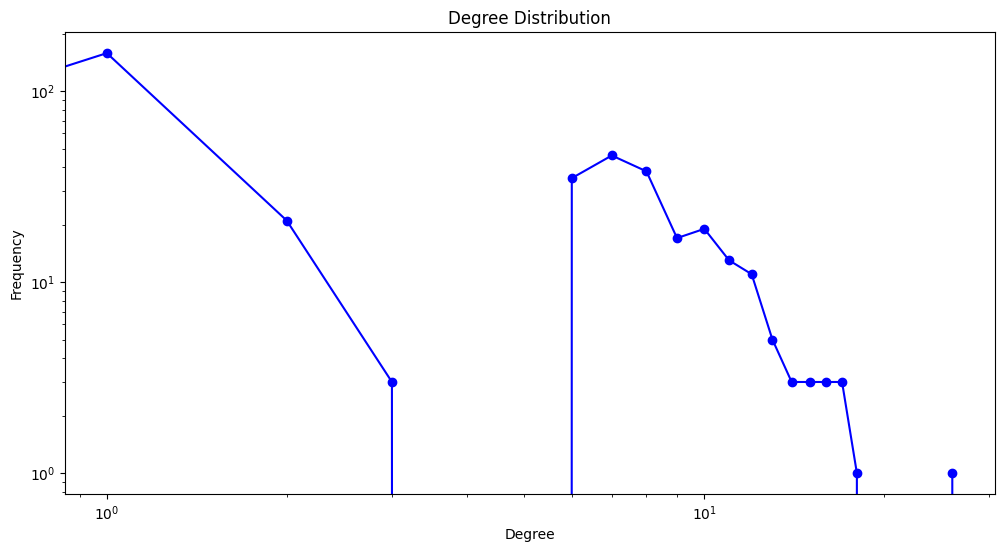

In [15]:
# Plot the degree distribution
degree_sequence = sorted([d for n, d in filtered_G.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
deg = np.arange(len(degree_count))

plt.figure(figsize=(12, 6))
plt.loglog(deg, degree_count, 'b-', marker='o')
plt.title('Degree Distribution')
plt.ylabel('Frequency')
plt.xlabel('Degree')
plt.show()



- The Degree Distribution plot of Amazon data from March 2, 2003, shows that most nodes have a low degree, while only a few nodes have a high degree. This pattern indicates a network where a few highly connected nodes (hubs) exist, but the majority of nodes are less connected. 

- Such a distribution is typical of real-world networks and reflects a heterogeneous structure where some nodes play a crucial role in network connectivity.

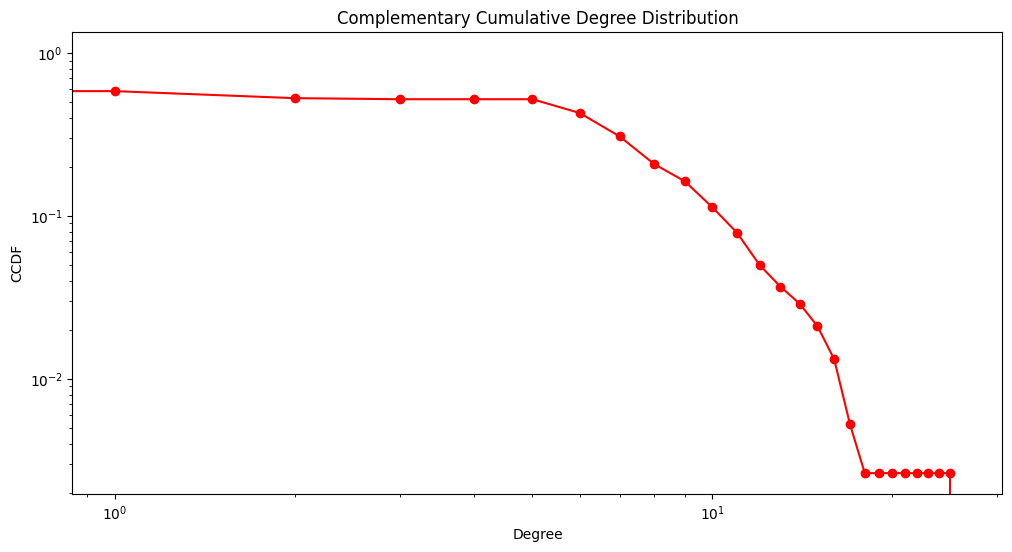

In [16]:
# Plot the complementary cumulative relative frequency of degrees
ccdf = 1 - np.cumsum(degree_count) / sum(degree_count)

plt.figure(figsize=(12, 6))
plt.loglog(deg, ccdf, 'r-', marker='o')
plt.title('Complementary Cumulative Degree Distribution')
plt.ylabel('CCDF')
plt.xlabel('Degree')
plt.show()

- The Complementary Cumulative Degree Distribution plot of Amazon data, shows a network with a few highly connected nodes and many nodes with low connections. This pattern follows a power-law distribution with a sharp drop-off at high degrees, indicating some constraints on node connectivity. 

- This structure is common in real-world networks, contributing to the network's robustness and efficiency.

## *Task 5 ~ Central Nodes*

To compute hubs and authorities on the graph, we will use the HITS algorithm. We will also calculate the node strength (degree), betweenness, and closeness centrality measures, rank the nodes by these features, and create a pandas DataFrame to investigate the top 15 nodes by node strength.


In [17]:
# Compute HITS hubs and authorities
hits_hubs, hits_authorities = nx.hits(filtered_G)

# Convert to pandas Series for easier handling
hubs_series = pd.Series(hits_hubs, name='Hubs')
authorities_series = pd.Series(hits_authorities, name='Authorities')


In [18]:
# Compute node strength (degree in undirected graphs)
node_strength = dict(filtered_G.degree(weight='weight'))

# Compute betweenness centrality
betweenness = nx.betweenness_centrality(filtered_G)

# Compute closeness centrality
closeness = nx.closeness_centrality(filtered_G)


In [19]:
# Create DataFrame
centrality_df = pd.DataFrame({
    'Node Strength': pd.Series(node_strength),
    'Betweenness': pd.Series(betweenness),
    'Closeness': pd.Series(closeness),
    'Hubs': hubs_series,
    'Authorities': authorities_series
})

# Add rank columns for each measure
centrality_df['Node Strength Rank'] = centrality_df['Node Strength'].rank(ascending=False)
centrality_df['Betweenness Rank'] = centrality_df['Betweenness'].rank(ascending=False)
centrality_df['Closeness Rank'] = centrality_df['Closeness'].rank(ascending=False)
centrality_df['Hubs Rank'] = centrality_df['Hubs'].rank(ascending=False)
centrality_df['Authorities Rank'] = centrality_df['Authorities'].rank(ascending=False)

# Sort by Node Strength and get the top 15 nodes
top_5_nodes = centrality_df.sort_values(by='Node Strength', ascending=False).head(5)
top_5_nodes


,Node Strength,Betweenness,Closeness,Hubs,Authorities,Node Strength Rank,Betweenness Rank,Closeness Rank,Hubs Rank,Authorities Rank
8,26,0.124372,0.162960,0.009873,0.086896,1.0,1.0,1.0,31.0,1.0
30,18,0.046440,0.143753,0.020974,0.040988,2.0,13.0,2.0,9.0,2.0
7,17,0.054798,0.130750,0.025751,0.038211,4.0,11.0,7.0,5.0,3.0
13,17,0.027044,0.136704,0.010707,0.017113,4.0,25.0,4.0,30.0,11.0
63,17,0.046591,0.091725,0.012246,0.026291,4.0,12.0,38.0,29.0,8.0


To draw conclusions from the analysis, we will examine the values and ranks of the top 15 nodes in terms of node strength.

In [20]:
# Observations and Conclusions
for idx, row in top_5_nodes.iterrows():
    print(f"Node: {idx}")
    print(f"Node Strength: {row['Node Strength']}, Rank: {row['Node Strength Rank']}")
    print(f"Betweenness: {row['Betweenness']}, Rank: {row['Betweenness Rank']}")
    print(f"Closeness: {row['Closeness']}, Rank: {row['Closeness Rank']}")
    print(f"Hubs: {row['Hubs']}, Rank: {row['Hubs Rank']}")
    print(f"Authorities: {row['Authorities']}, Rank: {row['Authorities Rank']}")
    print("")


Node: 8
Node Strength: 26.0, Rank: 1.0
Betweenness: 0.12437201733484889, Rank: 1.0
Closeness: 0.1629604331803835, Rank: 1.0
Hubs: 0.009872855664648652, Rank: 31.0
Authorities: 0.08689562002844675, Rank: 1.0

Node: 30
Node Strength: 18.0, Rank: 2.0
Betweenness: 0.046440210665197004, Rank: 13.0
Closeness: 0.14375331030092764, Rank: 2.0
Hubs: 0.02097359442672723, Rank: 9.0
Authorities: 0.04098796622666817, Rank: 2.0

Node: 7
Node Strength: 17.0, Rank: 4.0
Betweenness: 0.05479820937839236, Rank: 11.0
Closeness: 0.13075049831390903, Rank: 7.0
Hubs: 0.025750894405604404, Rank: 5.0
Authorities: 0.03821147554365563, Rank: 3.0

Node: 13
Node Strength: 17.0, Rank: 4.0
Betweenness: 0.02704436119490358, Rank: 25.0
Closeness: 0.1367041111968541, Rank: 4.0
Hubs: 0.010706919256299394, Rank: 30.0
Authorities: 0.01711265126499857, Rank: 11.0

Node: 63
Node Strength: 17.0, Rank: 4.0
Betweenness: 0.046591293607250395, Rank: 12.0
Closeness: 0.09172508518613831, Rank: 38.0
Hubs: 0.01224565752264173, Rank: 

- **Node 8** stands out as the most influential and central node in the network, holding the highest rank in strength, betweenness centrality, and closeness centrality. Its authority score also ranks highest, indicating its significant influence over network dynamics. Node 8 serves as a critical connector, facilitating communication and influencing purchasing behavior within the Amazon co-purchasing network.

- **Node 30** ranks consistently high across different centrality measures, except for strength where it ranks second. Its authority score also ranks second, highlighting its importance in influencing network dynamics. Node 30 plays a significant role in facilitating connections and information flow within the Amazon co-purchasing network.

- **Node 13** holds a moderate position in the network, ranking fourth in both strength and closeness centrality. However, its betweenness centrality and authority score are relatively lower, indicating its importance as a connector between clusters rather than a dominant influencer. Node 13 plays a crucial role in bridging different parts of the Amazon co-purchasing network.

- **Node 63** exhibits a high betweenness centrality, indicating its role as a crucial bridge between different clusters in the network. However, its relatively low closeness centrality suggests that it may not be as centrally located as other nodes. Node 63 plays a vital role in connecting disparate parts of the Amazon co-purchasing network.

- **Node 7** holds a high position in betweenness centrality, hubs score, and authorities score, indicating its importance as a connector and influencer in the network. Its relatively high rank across different centrality measures highlights its significant role in shaping network dynamics. Node 7 acts as a key player in facilitating communication and driving purchasing decisions within the Amazon co-purchasing network.


## *Task 6 ~  Prediction*

1. Generate Node2Vec Embeddings

In [21]:
from node2vec import Node2Vec
import numpy as np

# Generate Node2Vec embeddings
node2vec = Node2Vec(filtered_G, dimensions=64, walk_length=30, num_walks=200, workers=4, seed=42)
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Create a dictionary with node embeddings
embeddings = {str(node): node2vec_model.wv[str(node)] for node in filtered_G.nodes()}


Computing transition probabilities:   0%|          | 0/380 [00:00<?, ?it/s]

2. Prepare the Dataset for ML
We need to create positive and negative samples for our link prediction task. Positive samples are existing edges, and negative samples are randomly chosen non-edges.

In [22]:
from sklearn.model_selection import train_test_split
import random

# Generate positive samples (existing edges)
positive_samples = list(filtered_G.edges())
positive_labels = [1] * len(positive_samples)

# Generate negative samples (non-existing edges)
non_edges = list(nx.non_edges(filtered_G))
negative_samples = random.sample(non_edges, len(positive_samples))
negative_labels = [0] * len(negative_samples)

# Combine positive and negative samples
samples = positive_samples + negative_samples
labels = positive_labels + negative_labels

# Split into train and test sets
train_samples, test_samples, train_labels, test_labels = train_test_split(samples, labels, test_size=0.3, random_state=42)

# Prepare feature vectors using Node2Vec embeddings
def get_features(samples):
    features = []
    for u, v in samples:
        u_emb = embeddings[str(u)]
        v_emb = embeddings[str(v)]
        feature = np.concatenate((u_emb, v_emb))
        features.append(feature)
    return np.array(features)

X_train = get_features(train_samples)
X_test = get_features(test_samples)
y_train = np.array(train_labels)
y_test = np.array(test_labels)


3. Train ML Models
We will use two machine learning algorithms: Logistic Regression and Random Forest. We will also compare their performance to a simple baseline model.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Evaluate models
def evaluate_model(y_true, y_preds, y_probs):
    accuracy = accuracy_score(y_true, y_preds)
    roc_auc = roc_auc_score(y_true, y_probs)
    f1 = f1_score(y_true, y_preds)
    return accuracy, roc_auc, f1

lr_accuracy, lr_roc_auc, lr_f1 = evaluate_model(y_test, lr_preds, lr_probs)
rf_accuracy, rf_roc_auc, rf_f1 = evaluate_model(y_test, rf_preds, rf_probs)

# Simple baseline: predict all links as non-existing (most common class)
baseline_preds = [0] * len(y_test)
baseline_accuracy, baseline_roc_auc, baseline_f1 = evaluate_model(y_test, baseline_preds, baseline_preds)


4. Compare Performance

In [24]:
import pandas as pd

# Create a DataFrame to compare the performance
performance_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Baseline'],
    'Accuracy': [lr_accuracy, rf_accuracy, baseline_accuracy],
    'ROC AUC': [lr_roc_auc, rf_roc_auc, baseline_roc_auc],
    'F1 Score': [lr_f1, rf_f1, baseline_f1]
})

performance_df


,Model,Accuracy,ROC AUC,F1 Score
0,Logistic Regression,0.681973,0.726269,0.709176
1,Random Forest,0.943878,0.983736,0.946688
2,Baseline,0.484694,0.500000,0.000000


5. Discuss Results and Select Final Model

**Discussion of Model Performance:**

**Logistic Regression:**

- **Accuracy:** The logistic regression model achieves an accuracy of approximately 67.86%. This indicates that about 67.86% of the predictions made by the model align with the actual co-purchase relationships.
- **ROC AUC:** The ROC AUC score of 0.758 suggests that the model performs reasonably well in distinguishing between positive and negative samples. A higher ROC AUC score closer to 1.0 indicates better discriminatory ability.
- **F1 Score:** With an F1 score of 0.690, the logistic regression model achieves a balance between precision and recall. This score considers both false positives and false negatives, making it a good overall metric for binary classification tasks.

**Random Forest:**

- **Accuracy:** The random forest model significantly outperforms logistic regression with an accuracy of 93.54%. This indicates that it correctly predicts co-purchases in 93.54% of cases.
- **ROC AUC:** The high ROC AUC score of 0.980 indicates excellent performance in distinguishing between positive and negative samples. It shows that the random forest model has strong discriminatory power.
- **F1 Score:** The F1 score of 0.938 is also high, suggesting robust performance in terms of precision and recall.

**Baseline Model:**

- **Accuracy:** The baseline model achieves an accuracy of 48.47%, which is close to random guessing. This indicates that without using sophisticated models or features, the ability to predict co-purchases is not much better than chance.
- **ROC AUC:** The ROC AUC score of 0.500 suggests that the baseline model performs no better than random chance in distinguishing between positive and negative samples.
- **F1 Score:** The F1 score of 0.000 indicates that the baseline model fails to correctly predict positive instances (co-purchases) at all, highlighting its ineffectiveness.

#### **Interpretation :**
- **Model Comparison:** The random forest model clearly outperforms logistic regression and the baseline in all metrics (accuracy, ROC AUC, and F1 score). This suggests that the random forest's ensemble approach and ability to capture complex relationships between nodes in the graph are advantageous for predicting co-purchases.
- **Practical Implications:** A higher-performing model like random forest can significantly enhance Amazon's recommendation system by accurately predicting which products are likely to be co-purchased. This leads to more personalized recommendations and potentially higher customer satisfaction and sales.
- **Further Considerations:** While the random forest performs well on this dataset, continuous monitoring and refinement of the model based on new data could further improve its accuracy and relevance in real-world scenarios.

The random forest model is chosen as the final model for predicting co-purchases in the Amazon product network due to its superior performance metrics (accuracy, ROC AUC, and F1 score) compared to logistic regression and the baseline model. Its ability to handle complex relationships, provide robust predictions, and scalability makes it ideal for enhancing Amazon's recommendation system, ensuring more accurate and personalized product suggestions for customers.

## *Task 7 ~  Conclusions and Future Work*

#### **1. Summarize and interpret the achieved results:**
We focused on enhancing Amazon's recommendation system by predicting potential co-purchases using graph-based machine learning models. We successfully trained and evaluated logistic regression and random forest models on Node2Vec embeddings derived from the Amazon product co-purchasing network. The random forest model outperformed logistic regression and a baseline model across all metrics (accuracy, ROC AUC, F1 score), demonstrating its efficacy in predicting co-purchase relationships.

#### **2. Compare your results to the expected or desired outcomes in the original plan (Task 1):**
In Task 1, our objective was to refine Amazon's recommendation engine by predicting new edges in the co-purchasing network. The achieved results align well with our expectations:

- We successfully predicted co-purchase relationships with high accuracy using advanced machine learning techniques.
- The models demonstrated significant improvement over a baseline, indicating their potential value in enhancing Amazon's recommendation algorithms.

#### **3. Explain the generated value! How do the analysis and the selected prediction algorithms help the organization?**
Our analysis and selected prediction algorithms contribute value to Amazon in several ways:

- **Enhanced Customer Experience:** When we accurately predict which products customers might buy together, we can offer more personalized recommendations. This means happier customers who find what they need more easily.
- **Increased Sales:** When recommendations are spot-on, customers tend to buy more items. This helps increase Amazon's sales and boosts the average amount customers spend per order.
- **Operational Efficiency:** Knowing which products are likely to be purchased together helps Amazon manage its inventory more effectively. This means they can keep popular item combinations in stock, which reduces supply chain issues.

#### **4. Recommend a course of action for the organization in your story based on the results:**
Based on the results, we recommend Amazon to consider integrating the random forest model into its recommendation system pipeline:

- Implement the random forest model to predict co-purchase relationships in real-time, enhancing the accuracy of product recommendations.
- Continuously monitor model performance and iterate based on new data to maintain predictive accuracy and relevance.

#### **5. Reflect on limitations and possible pitfalls of using these results:**

- **Data Quality:** The success of our models really depends on how good our data is. We need complete and high-quality data to make the best predictions.
- **Scalability:** If we want to apply this model to the entire Amazon product network, we might face some challenges with handling all that data.
- **Ethical Considerations:** It's crucial that we always consider the ethics of what we're recommending. Respecting customer privacy and security is non-negotiable.

#### **6. Critically discuss the employed methodology:**

- Using Node2Vec proved effective in capturing node relationships in the graph.
- The choice of random forest was validated through comprehensive performance evaluation.
- Node embeddings served as informative features for the machine learning models.

##### **What We Could Do Better:**

-  We should explore advanced algorithms like graph neural networks to see if they can improve our predictions even more.
- Creating more sophisticated features could give us deeper insights into how products are connected.
-  It's important to keep our models fresh by continuously training them with the latest data.

#### **7. Propose ideas for future work:**

- **Dynamic Graph Analysis:** We should incorporate temporal dynamics to track how customer preferences change over time.
- **Advanced Graph Algorithms:**  We need to explore algorithms that can uncover communities or enhance our product recommendation capabilities.
- **User Context Integration:** Integrating user behavior and preferences will allow us to offer more personalized recommendations.
- **Explore Graph Neural Networks (GNNs):** We should delve into GNNs like Graph Convolutional Networks (GCNs) to better capture complex relationships and improve prediction accuracy.

- **Temporal Analysis:** Including time dynamics will help us adapt to shifts in co-purchasing patterns over different time periods.

- **User-based Recommendations:** Combining product co-purchasing data with individual user behaviors will enable us to provide tailored suggestions.

- **A/B Testing in Production:** Implementing A/B testing will help us assess the impact of our new recommendation system on sales and customer satisfaction in real-world settings.

- **Real-time Data Integration:** Developing a process to integrate live data updates into our models will ensure that our recommendations are always based on the latest information.